# Regression Visualization

## Datasets

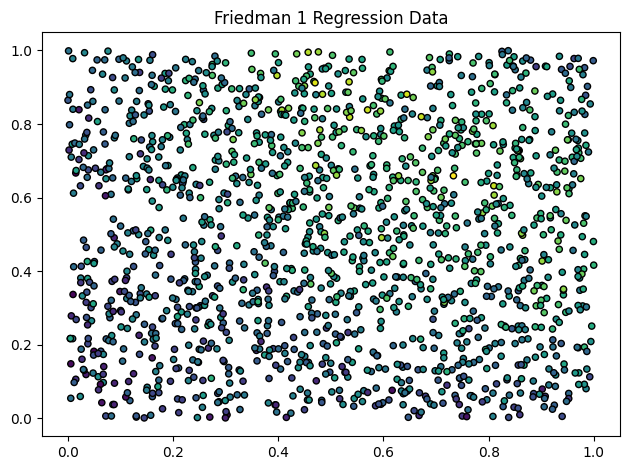

In [84]:
# Create regression data using make_friedman1 and plot it
from sklearn.datasets import make_friedman1
import matplotlib.pyplot as plt
import numpy as np
X1, y1 = make_friedman1(n_samples=1500, n_features=10, random_state=44)
plt.scatter(X1[:, 0], X1[:, 1], c=y1, edgecolors='k', cmap='viridis', s=20)
plt.title("Friedman 1 Regression Data")
plt.tight_layout()
plt.show()

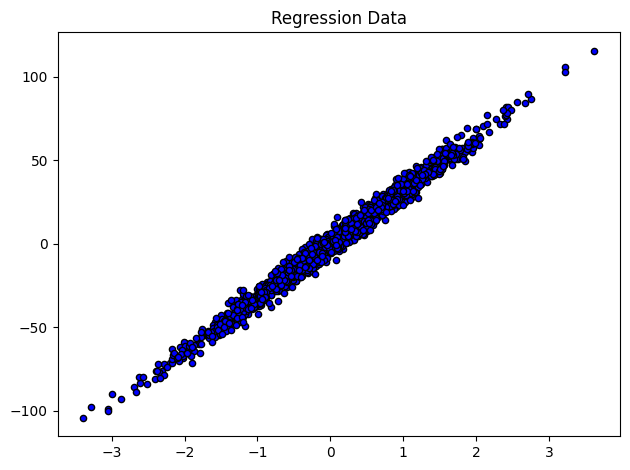

In [85]:
# Create regression data using make_regression
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=1500, n_features=1, noise=4)

# Visualize the data
import matplotlib.pyplot as plt
plt.scatter(X, y, edgecolors='k', color='blue', s=20)
plt.title("Regression Data")
plt.tight_layout()
plt.show()

## Data Splitting

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=44)

## Pipeline

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge()) # Replace with any Regressor
])

## Evaluation Function
In regression, we measure how far our predictions are from the actual values.

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_regression(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- Regression Metrics ---")
    print(f"Mean Squared Error (MSE):      {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"R2 Score (Variance Explained):  {r2:.4f}")
    return y_pred

## Plotting Function
We use two main plots:
1. **Actual vs Predicted**: A perfect model follows the 45-degree line.
2. **Residual Plot**: Errors should be randomly scattered around zero.

In [89]:
def plot_regression_results(y_test, y_pred, model_name="Model"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Actual vs Predicted
    ax1.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Predicted Values')
    ax1.set_title(f'{model_name}: Actual vs Predicted')
    
    # Plot 2: Residuals
    residuals = y_test - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.5, edgecolors='k')
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('Predicted Values')
    ax2.set_ylabel('Residuals (Actual - Predicted)')
    ax2.set_title(f'{model_name}: Residual Plot')
    
    plt.tight_layout()
    plt.show()

## Model Traning

### Linear Regression

Linear Regression R^2 on Data: 0.7447


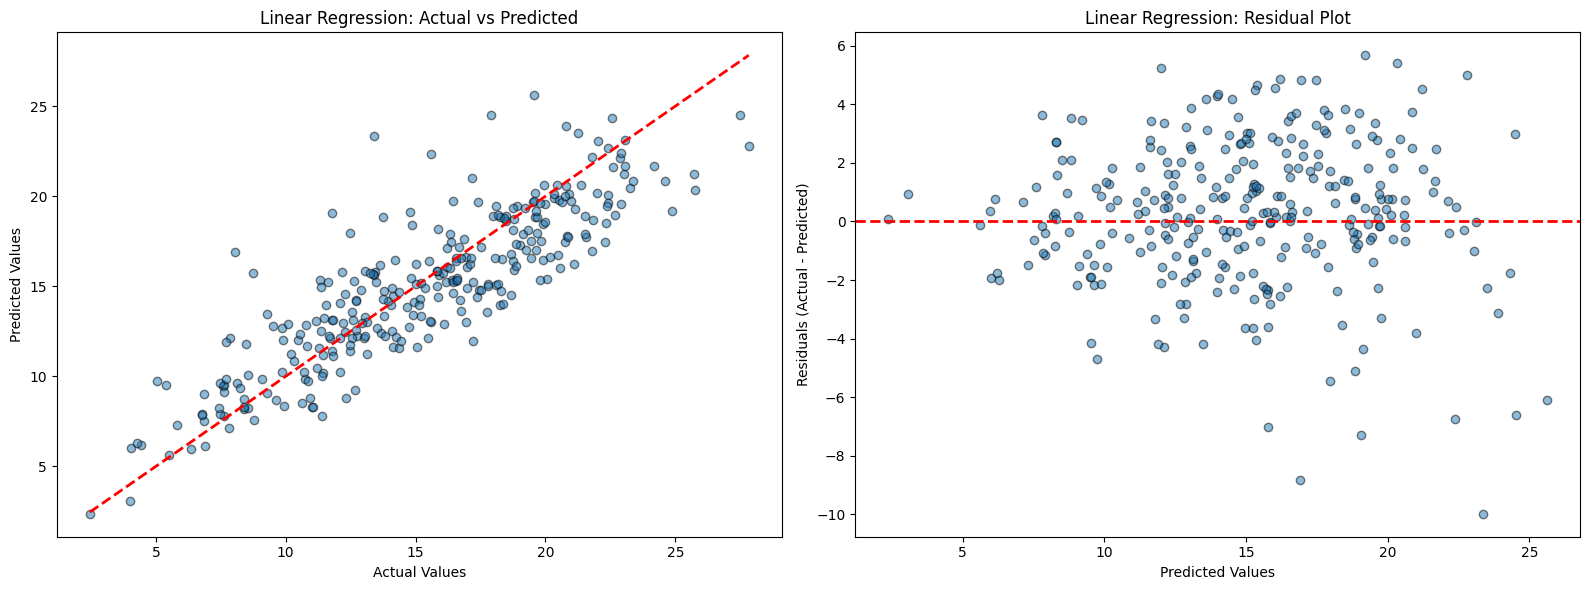

--- Regression Metrics ---
Mean Squared Error (MSE):      6.1867
Root Mean Squared Error (RMSE): 2.4873
Mean Absolute Error (MAE):     1.8982
R2 Score (Variance Explained):  0.7447


array([15.0371488 , 20.60857637, 19.0529832 , 15.13588017,  5.99537521,
       22.81259855, 15.04875034, 14.70970903, 13.23377236, 19.9223326 ,
       14.77039433, 19.76168072, 22.35497753, 19.68165243, 13.31500694,
       23.09702631, 17.15275441, 12.71691389, 12.11275759, 14.14297938,
       12.47067275, 20.07455075,  8.80416362,  9.47768845, 13.97259087,
       13.97866603,  7.50825638, 17.26812453, 15.78848406, 17.88680201,
        8.75774392, 14.40129402, 10.26067334, 12.40385234, 13.41312579,
       15.35451505, 11.62686469, 13.00407871, 20.6227493 , 19.12604681,
       12.23186002, 19.74478269, 17.81492499, 16.46807308, 20.84027006,
       16.08216159, 15.48363775, 12.84509662, 22.67281277, 16.22725136,
        7.79188535, 15.13198222, 10.16401827, 12.24556478, 17.0056618 ,
       17.43724995, 10.26342832, 20.16841605,  9.02697246, 13.57387412,
        8.67245759, 16.55391623, 12.13147336, 16.99898898, 19.67967508,
       12.81220929, 16.20336011,  9.84286687, 12.87848883, 14.04

In [90]:
from sklearn.linear_model import LinearRegression

reg_pipe.set_params(model=LinearRegression())
reg_pipe.fit(X_train, y_train)
print(f"Linear Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Linear Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Ridge Regression

Ridge Regression R^2 on Data: 0.7447


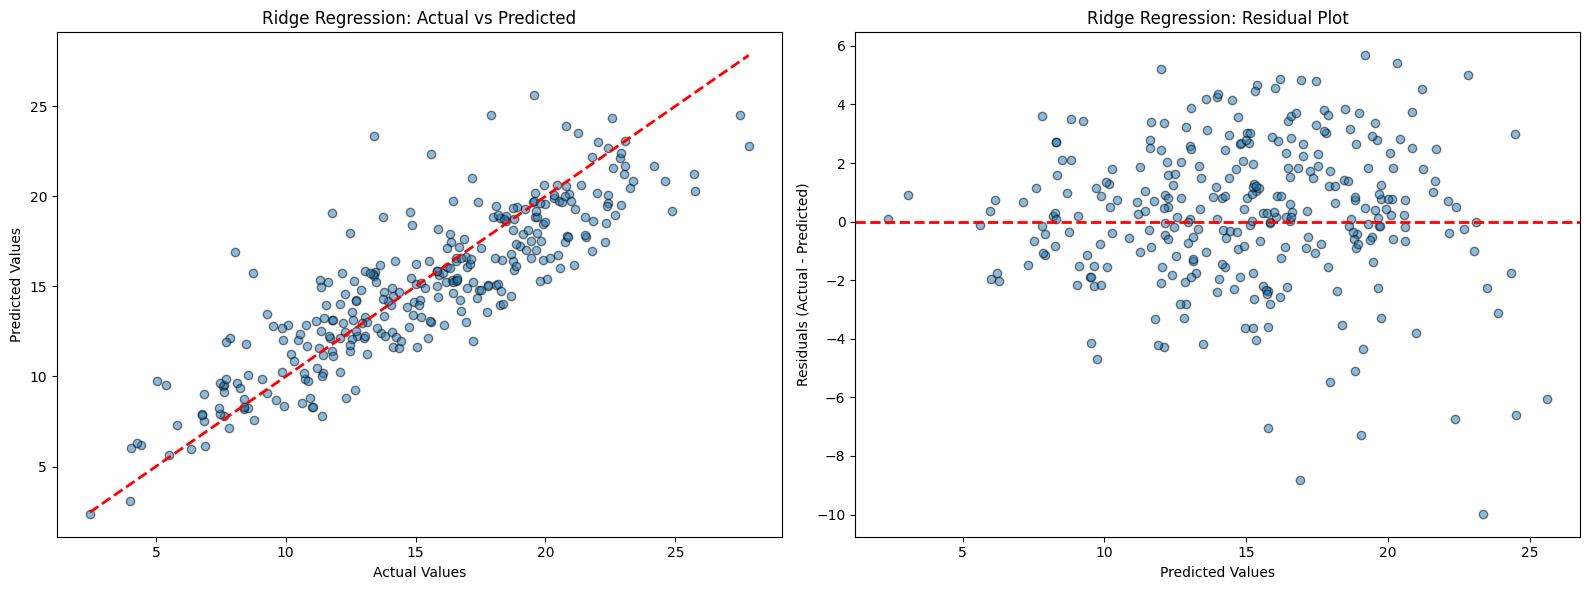

--- Regression Metrics ---
Mean Squared Error (MSE):      6.1868
Root Mean Squared Error (RMSE): 2.4873
Mean Absolute Error (MAE):     1.8984
R2 Score (Variance Explained):  0.7447


array([15.03662803, 20.60402969, 19.0487854 , 15.13494111,  6.00313616,
       22.80599563, 15.04861274, 14.70953825, 13.23480994, 19.91781129,
       14.77067015, 19.75666569, 22.34803222, 19.67736726, 13.31520341,
       23.0897505 , 17.1508212 , 12.71842389, 12.11599294, 14.14300412,
       12.47261228, 20.06955882,  8.80902443,  9.48211274, 13.97304543,
       13.97834288,  7.51382146, 17.26618533, 15.78827328, 17.88365096,
        8.76276193, 14.40150545, 10.26330764, 12.40525786, 13.41345616,
       15.35380841, 11.62930083, 13.00469776, 20.61803644, 19.12284786,
       12.2332818 , 19.73940646, 17.81090235, 16.46677818, 20.83537366,
       16.08068391, 15.48261682, 12.84595019, 22.66514432, 16.22624572,
        7.79752983, 15.13070119, 10.16688155, 12.24736212, 17.00241122,
       17.4338749 , 10.26643161, 20.16323084,  9.03085476, 13.57379192,
        8.67756177, 16.55282705, 12.13333179, 16.99659152, 19.67573527,
       12.81309116, 16.20277225,  9.84634803, 12.88021903, 14.04

In [91]:
from sklearn.linear_model import Ridge

reg_pipe.set_params(model=Ridge(alpha=1))
reg_pipe.fit(X_train, y_train)
print(f"Ridge Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Ridge Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Lasso Regression

Lasso Regression R^2 on Data: 0.7434


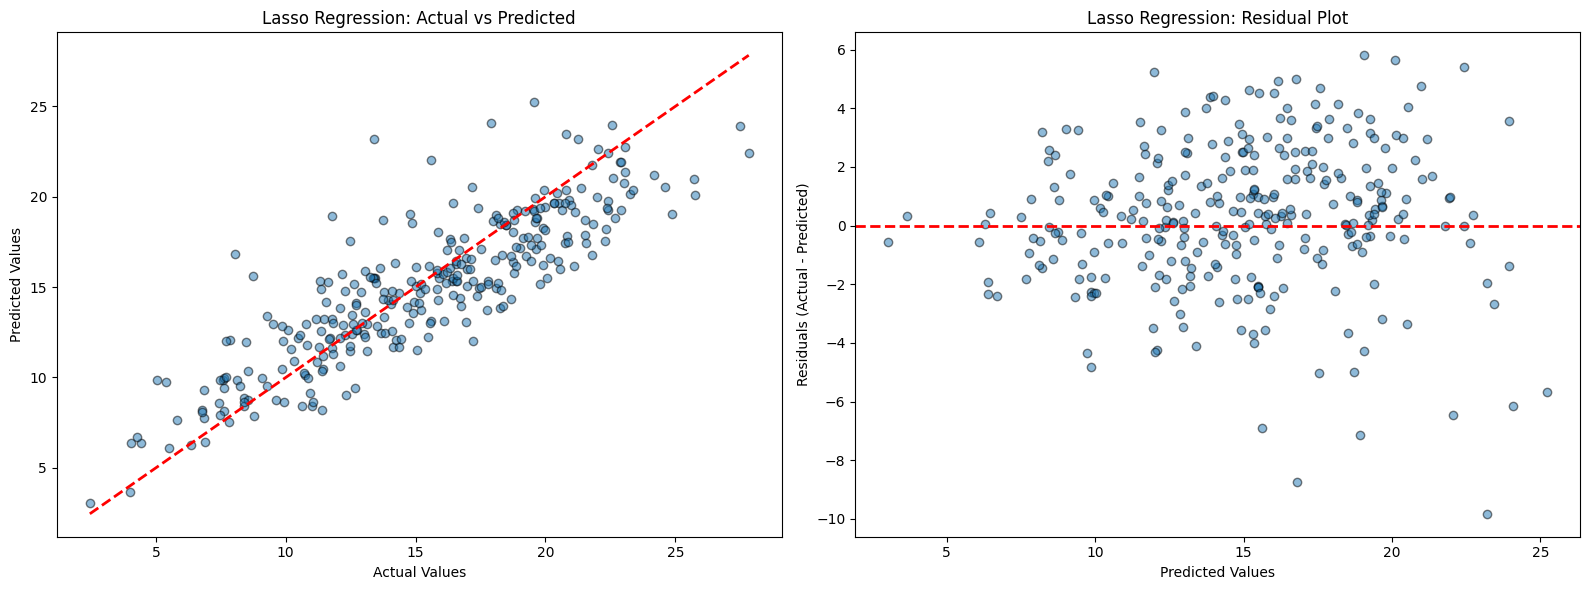

--- Regression Metrics ---
Mean Squared Error (MSE):      6.2177
Root Mean Squared Error (RMSE): 2.4935
Mean Absolute Error (MAE):     1.9081
R2 Score (Variance Explained):  0.7434


array([14.87575709, 20.45617588, 18.91202851, 15.06524918,  6.38624816,
       22.41186026, 14.94122747, 14.73015232, 13.20971943, 19.6712997 ,
       14.7070599 , 19.63242999, 22.04992538, 19.33403992, 13.61910311,
       22.72518095, 17.10628573, 13.02179818, 12.07074184, 14.16571372,
       12.3590583 , 19.75311757,  9.02414908,  9.8720097 , 14.1608825 ,
       14.08671236,  7.78050331, 17.13998468, 15.49879285, 17.64473637,
        8.8808629 , 14.27113457, 10.44316362, 12.4478606 , 13.55664726,
       15.32093128, 11.50370665, 13.11008655, 20.21539689, 19.05111151,
       12.46412674, 19.65226961, 17.84656003, 16.2378983 , 20.5298305 ,
       15.9866821 , 15.3407179 , 12.93697409, 22.41952654, 16.01880912,
        8.14856565, 15.19960611, 10.44557442, 12.63196788, 17.08595751,
       17.46914395, 10.60922191, 19.92980438,  9.31576945, 13.75021003,
        8.77493387, 16.25539642, 12.16705895, 16.72444877, 19.26226434,
       12.97109355, 16.03444061,  9.9577799 , 12.64594464, 13.81

In [92]:
from sklearn.linear_model import Lasso

reg_pipe.set_params(model=Lasso(alpha=0.1))
reg_pipe.fit(X_train, y_train)
print(f"Lasso Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Lasso Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### SVR

SVR R^2 on Data: 0.9845


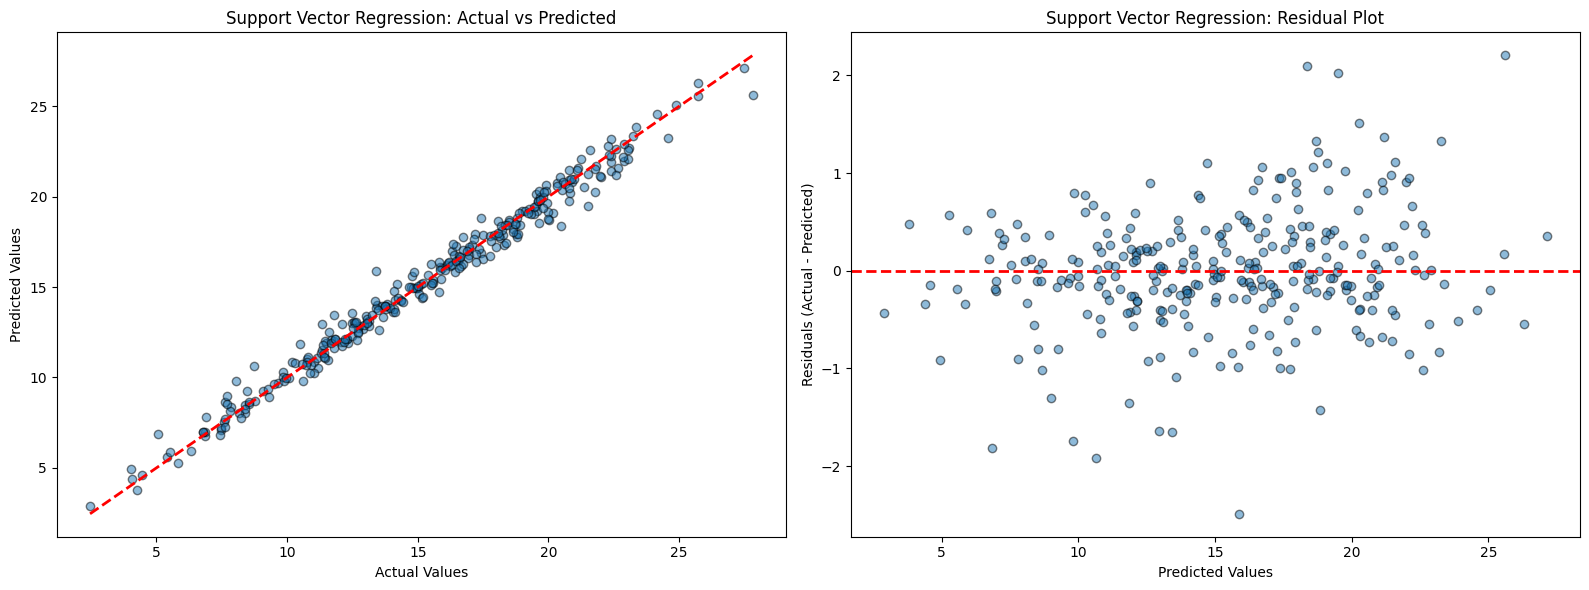

--- Regression Metrics ---
Mean Squared Error (MSE):      0.3763
Root Mean Squared Error (RMSE): 0.6134
Mean Absolute Error (MAE):     0.4445
R2 Score (Variance Explained):  0.9845


array([16.12950514, 20.56133688, 13.43035392, 14.92512084,  4.39161764,
       25.61821339, 18.68244365, 13.96141515, 11.90742694, 20.73208753,
       12.69294362, 20.34479503, 15.41423185, 19.48703884, 13.06683471,
       22.69080104, 17.87847882, 15.02785872,  8.39139958, 14.92991224,
       12.10371502, 21.92842509, 11.88625161,  7.53069672, 10.98897131,
       13.63953657,  6.74701844, 19.2157404 , 14.00575279, 16.9817046 ,
        8.05476551, 15.43160896, 10.30314554, 13.35706214, 14.94695438,
       16.77247993, 14.63257848, 15.20620603, 21.10775015, 15.62423434,
       14.07207155, 17.28233105, 20.21833521, 20.62377999, 23.26091919,
       17.13472619, 14.92758145, 11.01437725, 22.2415069 , 17.32080637,
        7.71539992, 17.73101977, 11.05471456, 12.84259625, 18.57178179,
       17.36271598, 11.98749498, 19.78405614,  6.98107125, 17.85361361,
        9.71395475, 16.72684185, 11.7577102 , 19.3119242 , 20.70221523,
        9.638124  , 13.95696266,  9.23492014,  9.98490575, 12.97

In [93]:
from sklearn.svm import SVR

reg_pipe.set_params(model=SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1))
reg_pipe.fit(X_train, y_train)
print(f"SVR R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Support Vector Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Regression Trees

Decision Tree Regression R^2 on Data: 0.7410


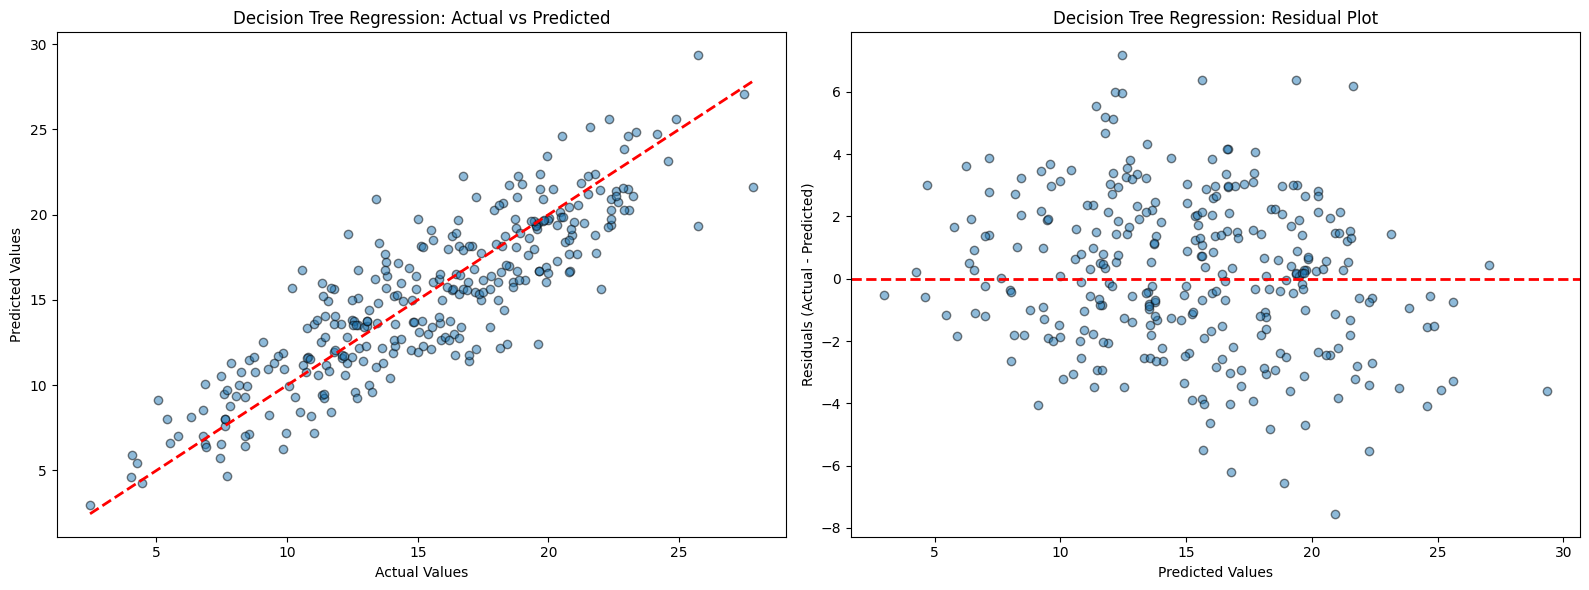

--- Regression Metrics ---
Mean Squared Error (MSE):      6.2758
Root Mean Squared Error (RMSE): 2.5052
Mean Absolute Error (MAE):     2.0273
R2 Score (Variance Explained):  0.7410


array([13.64097322, 19.48325732, 15.64366405, 19.73384103,  5.88951462,
       21.64038885, 16.04675438, 17.19985451, 11.16068963, 17.29673841,
       11.41344081, 24.59202295, 18.5368934 , 19.37826221, 13.48597498,
       20.25519816, 16.15349562, 12.04924447, 11.31969207, 15.64366405,
       12.83856119, 20.92831543, 18.87268583,  9.50797403, 14.91494289,
       11.90623487,  6.57364622, 21.80786473, 13.65785035, 15.60698216,
        9.31821027, 12.62289158, 11.90623487, 11.2830719 , 16.42436209,
       13.02720607, 13.11691713, 16.03042056, 20.17232571, 15.01249752,
       16.42436209, 16.5367352 , 16.68306243, 16.04675438, 23.13942996,
       11.41344081, 13.72244696, 13.3296473 , 19.39858906, 18.14971304,
        7.62484403, 12.16744562, 14.076995  , 12.2062565 , 16.68306243,
       15.64366405, 13.56922428, 19.50004451, 10.09780818, 13.4378147 ,
       11.68499447, 15.34009325, 11.58131826, 18.64063708, 18.39368652,
       11.28007457, 12.19777504, 12.54294638,  9.97386885, 11.76

In [94]:
from sklearn.tree import DecisionTreeRegressor

reg_pipe.set_params(model=DecisionTreeRegressor(random_state=44))
reg_pipe.fit(X_train, y_train)
print(f"Decision Tree Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Decision Tree Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Polynomial Regression

Polynomial Regression R^2 on Data: 0.9957


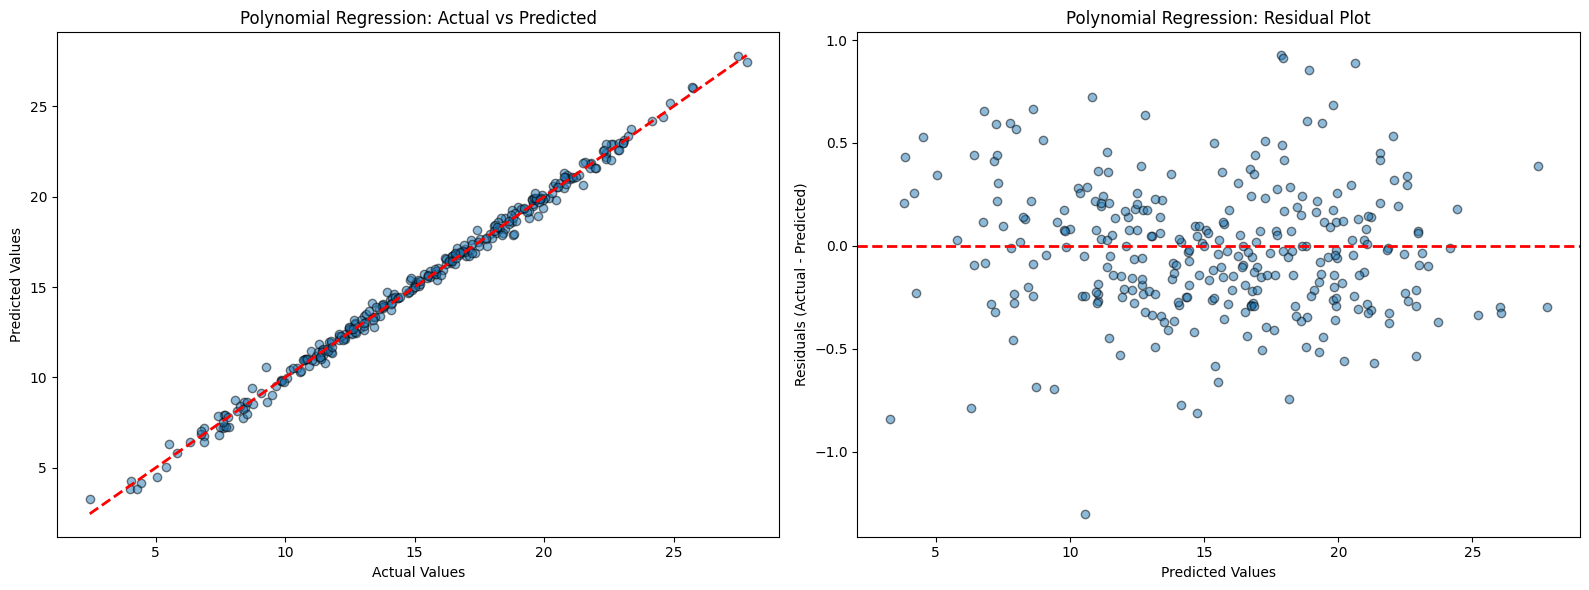

--- Regression Metrics ---
Mean Squared Error (MSE):      0.1030
Root Mean Squared Error (RMSE): 0.3210
Mean Absolute Error (MAE):     0.2489
R2 Score (Variance Explained):  0.9957


array([15.73073767, 21.21308117, 11.41636814, 15.19087489,  4.28154401,
       27.43349591, 18.37010341, 13.84876314, 11.23862251, 20.57925873,
       12.72359986, 20.56288538, 15.88564292, 19.89329409, 13.40597172,
       23.11385306, 17.65585068, 14.66041919,  7.24846584, 14.93607769,
       12.15497114, 22.43408025, 12.38304645,  7.18259052, 10.82915488,
       14.30690238,  6.74566377, 19.44565344, 12.79850521, 16.5133784 ,
        8.64123524, 15.37879035,  9.86529089, 13.42852171, 14.81818918,
       16.3405381 , 15.30917842, 15.55367647, 20.74026736, 14.73212488,
       13.93377232, 16.74265329, 20.96520164, 19.9171866 , 24.41033681,
       16.72871952, 15.41858673, 11.04166005, 22.20760977, 16.71705322,
        7.32874279, 17.98844543, 11.49584016, 12.48617327, 19.83837831,
       16.45527883, 12.29439429, 19.46857623,  6.4296747 , 17.67348629,
        9.52475198, 16.26656221, 12.09489293, 19.31734356, 20.76908126,
        9.00442481, 13.8065126 ,  9.11656295,  9.98862271, 12.37

In [95]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_features = PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
reg_pipe.set_params(model=Pipeline([
    ('poly', polynomial_features(degree=3)),
    ('linear', LinearRegression())
]))
reg_pipe.fit(X_train, y_train)
print(f"Polynomial Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Polynomial Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### K-Nearest Neighbour (KNN) Regressor

KNN Regression R^2 on Data: 0.7574


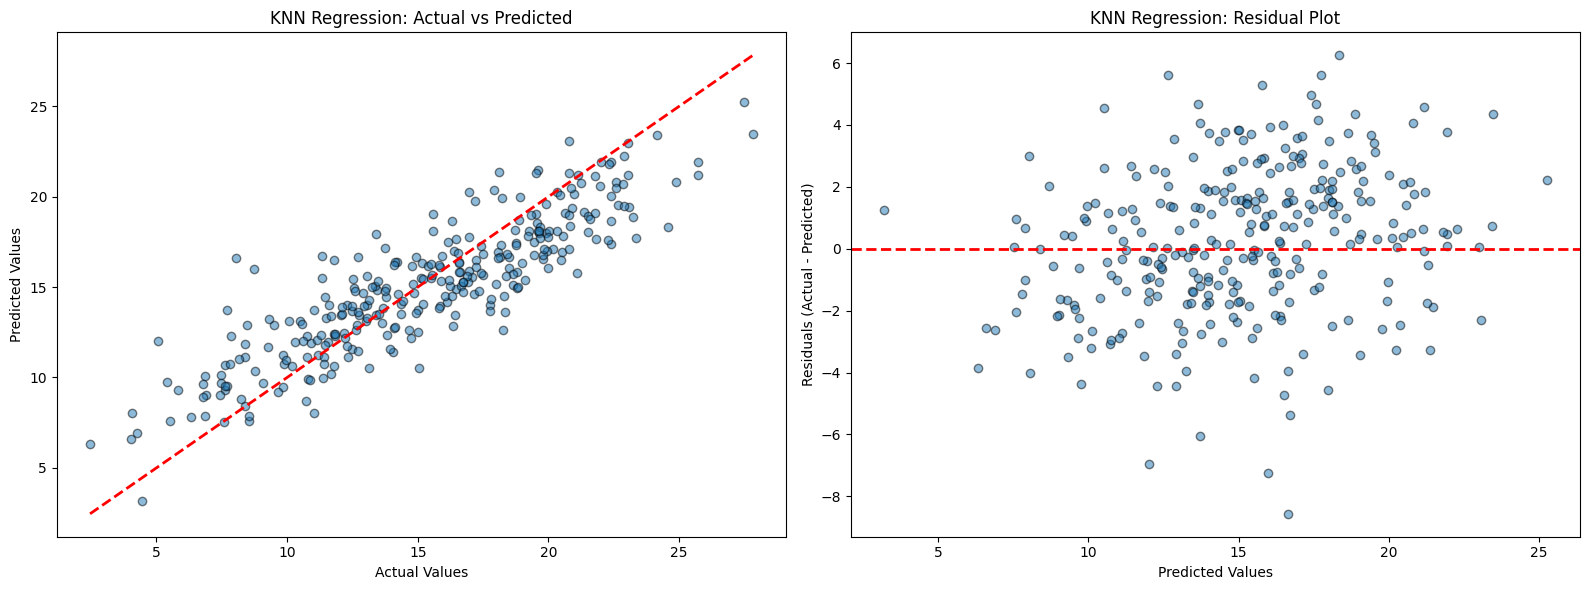

--- Regression Metrics ---
Mean Squared Error (MSE):      5.8784
Root Mean Squared Error (RMSE): 2.4245
Mean Absolute Error (MAE):     1.9511
R2 Score (Variance Explained):  0.7574


array([13.9788689 , 19.15308629, 16.49814421, 13.71238846,  8.05730067,
       23.48409604, 16.95298761, 14.95257427, 13.26634911, 20.28042977,
       14.67046617, 16.93826509, 19.03559774, 19.05900116, 13.99072265,
       19.40398785, 15.68914388, 12.1941162 , 12.2728654 , 16.66801959,
       14.0222747 , 18.65096835, 11.10635343,  7.53117146, 11.9362931 ,
       11.40060711, 10.08336209, 16.355664  , 14.82285083, 18.63307964,
        8.40136065, 15.35065529,  9.45364392, 13.85712071, 13.5546421 ,
       17.01350631, 10.50942013, 18.09268547, 20.09736648, 16.15021043,
       12.37059601, 14.88150305, 18.37154636, 18.01073787, 18.33738747,
       17.78308749, 15.14642204, 11.11487915, 21.92505389, 15.54447961,
        9.2958928 , 16.65993782, 11.80470631, 13.47788685, 17.98767905,
       12.83378004, 13.43691397, 21.46033042,  7.89580469, 14.00144099,
        9.18749451, 16.37460443, 13.49555811, 18.12707826, 19.08929756,
       12.92371553, 13.02335198,  9.69973926, 13.11916665, 13.91

In [96]:
from sklearn.neighbors import KNeighborsRegressor

reg_pipe.set_params(model=KNeighborsRegressor(n_neighbors=5))
reg_pipe.fit(X_train, y_train)
print(f"KNN Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="KNN Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Random Forest Regressor

Random Forest Regression R^2 on Data: 0.8997


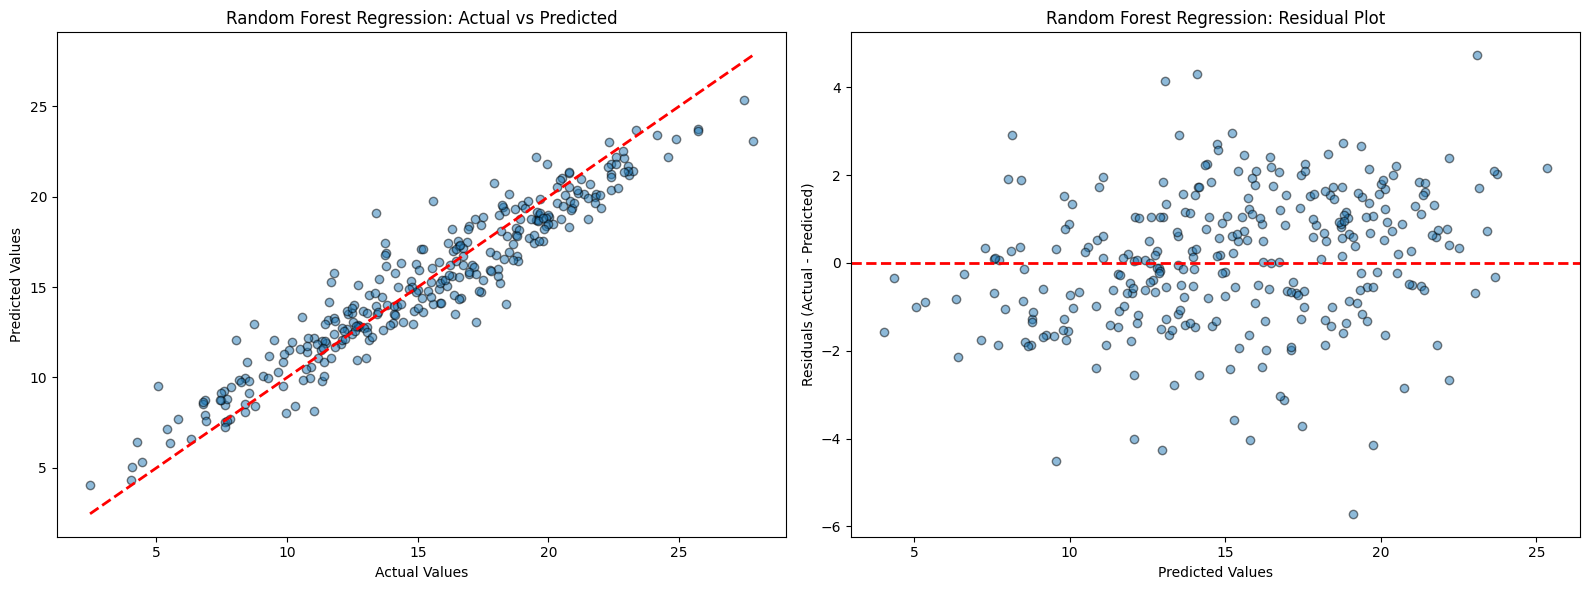

--- Regression Metrics ---
Mean Squared Error (MSE):      2.4307
Root Mean Squared Error (RMSE): 1.5591
Mean Absolute Error (MAE):     1.2472
R2 Score (Variance Explained):  0.8997


array([14.10713993, 20.1363047 , 15.80062471, 14.84251053,  5.05897898,
       23.09757233, 15.98519329, 16.87737567, 11.93068969, 19.66175764,
       13.66649502, 21.01255286, 19.73704212, 18.71253852, 12.8015483 ,
       21.22694858, 18.88841391, 15.31342976,  9.49893174, 16.2677724 ,
       12.67779643, 20.38561821, 13.48907342,  9.23090356, 13.19785823,
       13.00895566,  7.9172304 , 19.54533081, 13.48576174, 15.59777245,
        9.95079056, 14.14452788, 10.84057398, 12.60341078, 14.74669848,
       14.55706101, 15.96387201, 14.04208544, 20.91699734, 14.99633894,
       13.98310807, 16.46905849, 19.76244406, 18.35932215, 22.20415912,
       15.74733738, 12.98385947, 11.39708041, 21.27740202, 16.19583565,
        8.49561476, 15.21034758, 12.94825908, 12.8669129 , 18.98994758,
       16.99892241, 11.87137884, 18.71050616,  8.74973045, 15.97086463,
       10.30839547, 15.53709971, 12.05507382, 17.72204566, 20.11044664,
       12.05901942, 14.43349373, 10.10189807, 11.5380099 , 12.75

In [97]:
from sklearn.ensemble import RandomForestRegressor
reg_pipe.set_params(model=RandomForestRegressor(n_estimators=100, random_state=44))
reg_pipe.fit(X_train, y_train)
print(f"Random Forest Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Random Forest Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Gradient Boosting Machines (GBMs)

Gradient Boosting Regression R^2 on Data: 0.9597


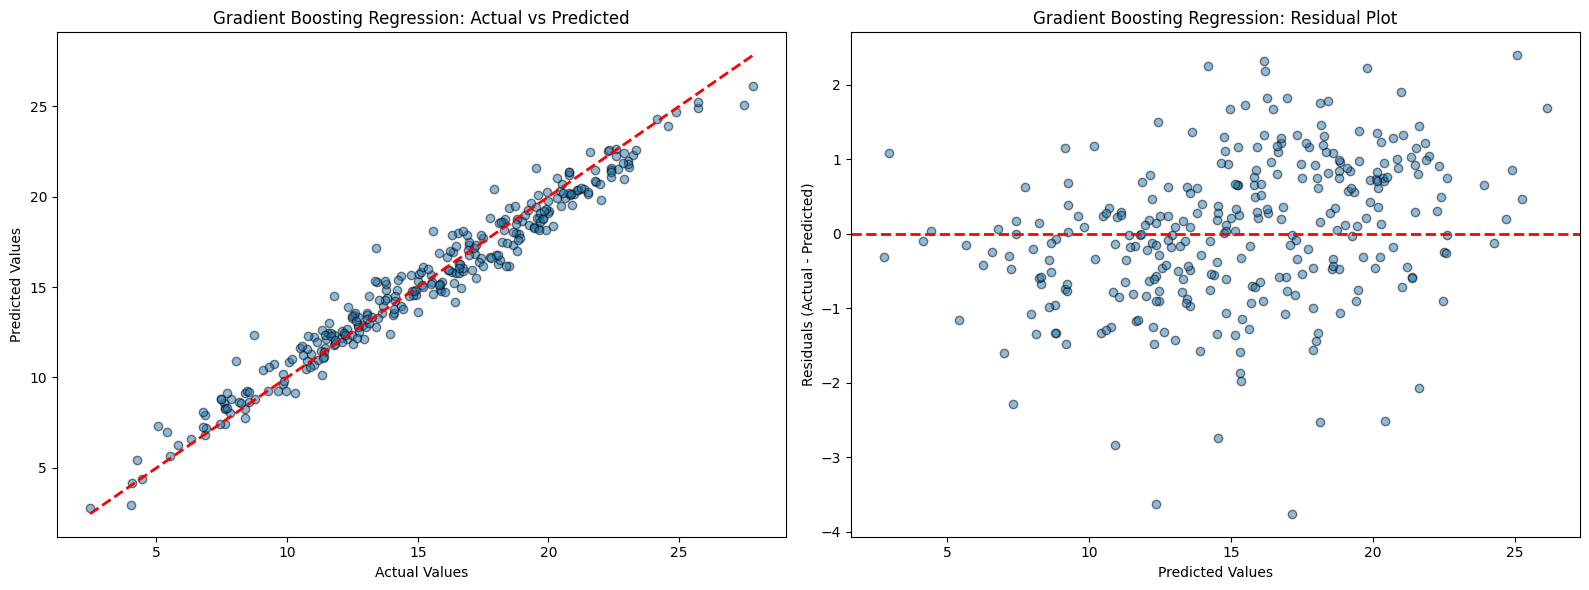

--- Regression Metrics ---
Mean Squared Error (MSE):      0.9755
Root Mean Squared Error (RMSE): 0.9877
Mean Absolute Error (MAE):     0.7759
R2 Score (Variance Explained):  0.9597


array([14.9045152 , 20.40679479, 14.52344186, 15.34444856,  4.14122082,
       26.12875086, 16.2538489 , 14.82743439, 12.11155361, 19.90384484,
       12.91827459, 20.69825036, 18.12738989, 19.4233933 , 13.55521574,
       21.62680831, 17.71883411, 15.68983109,  8.79238318, 14.82836299,
       12.11004396, 21.59324239, 13.89507432,  8.5729693 , 12.45540652,
       13.43690866,  6.79577362, 18.65249168, 15.30263915, 15.83353811,
        9.14174332, 14.77527905, 10.19810789, 13.94021348, 14.53659861,
       15.23223933, 15.75127439, 14.6297412 , 20.29838574, 14.7673018 ,
       14.39222239, 15.80668642, 20.10092535, 18.13824701, 23.92879829,
       17.31421114, 14.54977077, 10.90990077, 21.07107322, 15.91852004,
        8.30892689, 16.47438149, 11.61522922, 12.50706026, 18.7946113 ,
       16.94117322, 12.1981897 , 18.27539828,  7.94442459, 16.64112937,
        9.26133863, 15.80457416, 11.98044246, 18.4232553 , 19.90702741,
       10.76588619, 13.5509165 , 10.4044781 , 10.85260753, 12.55

In [102]:
from sklearn.ensemble import GradientBoostingRegressor
reg_pipe.set_params(model=GradientBoostingRegressor(n_estimators=100, random_state=44))
reg_pipe.fit(X_train, y_train)
print(f"Gradient Boosting Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Gradient Boosting Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Elastic Net

ElasticNet Regression R^2 on Data: 0.7409


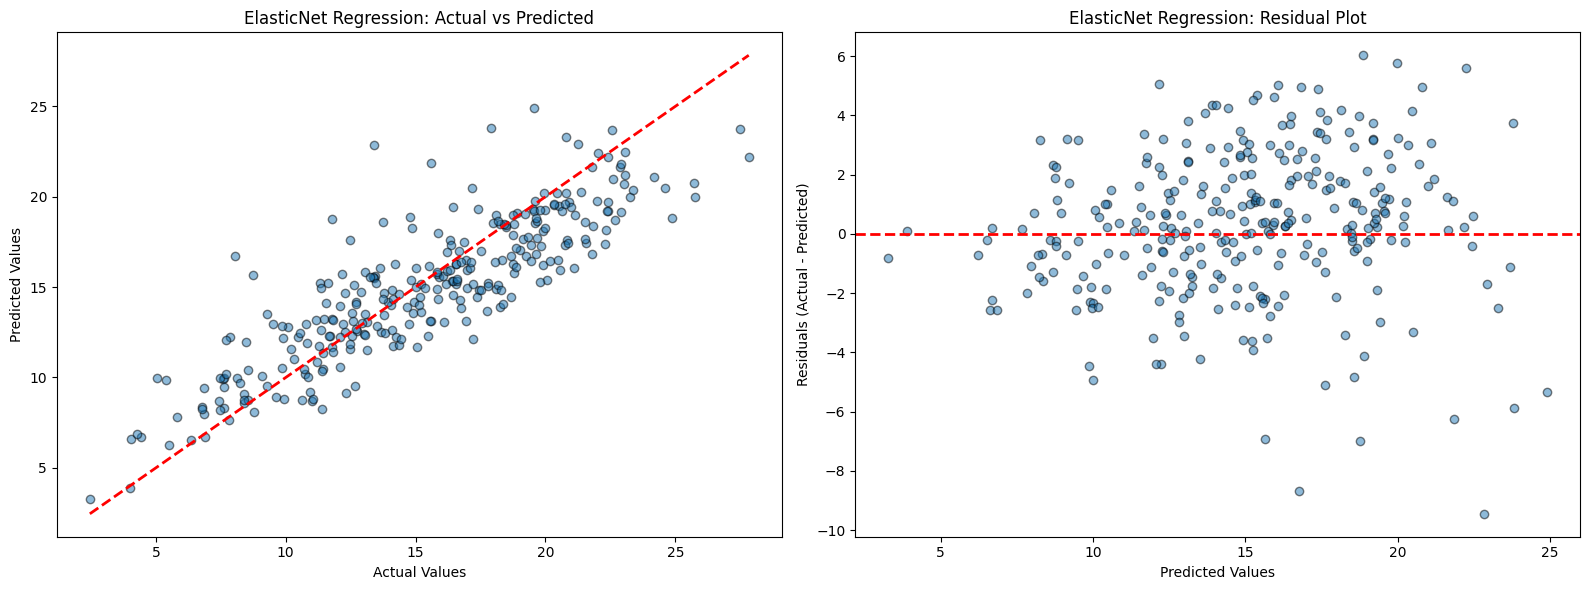

--- Regression Metrics ---
Mean Squared Error (MSE):      6.2790
Root Mean Squared Error (RMSE): 2.5058
Mean Absolute Error (MAE):     1.9334
R2 Score (Variance Explained):  0.7409


array([14.90373112, 20.27612891, 18.76598419, 15.02547551,  6.62296799,
       22.2208141 , 14.9180623 , 14.67341679, 13.24536724, 19.552738  ,
       14.73279299, 19.46520091, 21.84906657, 19.31495753, 13.50761367,
       22.46216   , 16.98963697, 12.95140936, 12.22220518, 14.18317038,
       12.51075983, 19.69141902,  9.13493759,  9.9025917 , 14.09444741,
       14.0309444 ,  7.96330125, 17.06746623, 15.63723021, 17.60356672,
        9.10558477, 14.33668536, 10.50474543, 12.51997299, 13.55899878,
       15.31716683, 11.66211028, 13.12983194, 20.18331361, 18.90336663,
       12.45845824, 19.42958799, 17.62807388, 16.21596379, 20.45716413,
       15.92849708, 15.37309523, 12.95432678, 22.17934363, 16.04276474,
        8.31226148, 15.13406026, 10.44848454, 12.55048131, 16.84993484,
       17.30904463, 10.58421834, 19.78307566,  9.43607872, 13.67443254,
        8.94302756, 16.30099581, 12.26389077, 16.70504535, 19.22751996,
       12.9725489 , 16.08295946, 10.09299482, 12.81701131, 13.93

In [101]:
from sklearn.linear_model import ElasticNet
reg_pipe.set_params(model=ElasticNet(alpha=0.1, l1_ratio=0.5))
reg_pipe.fit(X_train, y_train)
print(f"ElasticNet Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="ElasticNet Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Kernel Ridge Regression

Kernel Ridge Regression R^2 on Data: 0.8834


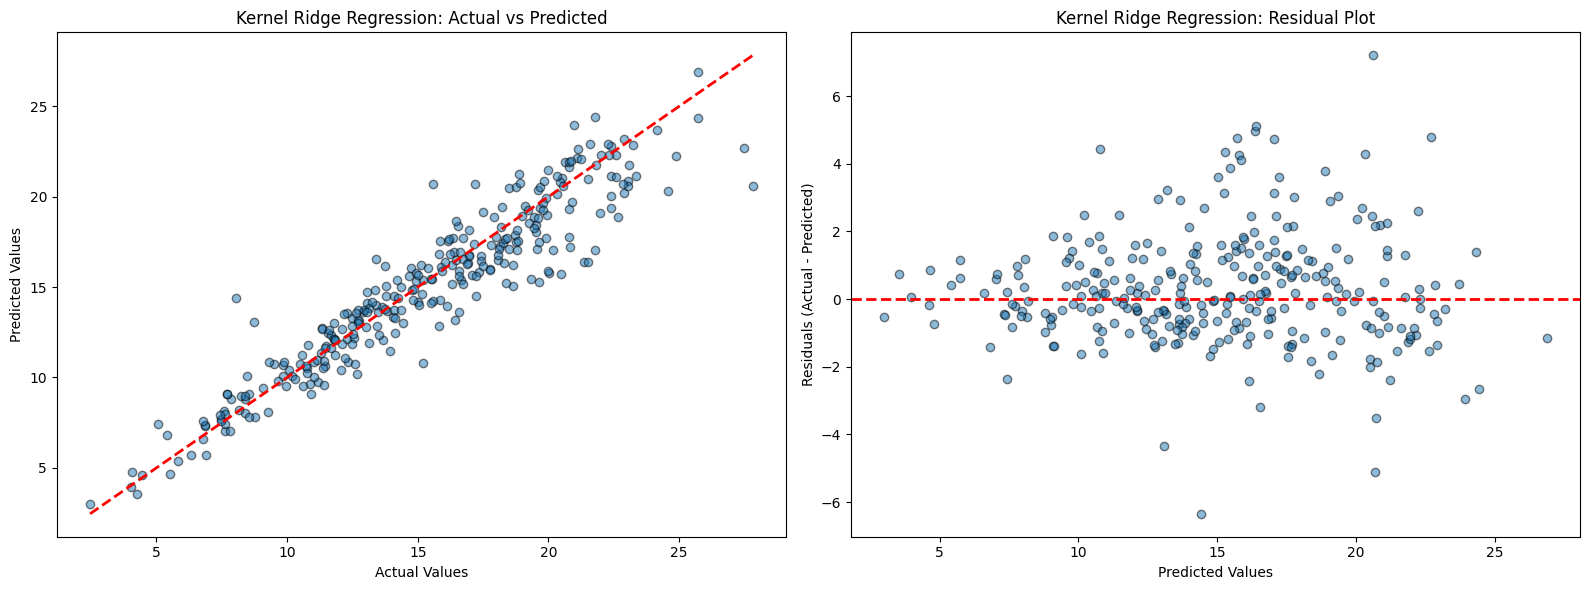

--- Regression Metrics ---
Mean Squared Error (MSE):      2.8252
Root Mean Squared Error (RMSE): 1.6808
Mean Absolute Error (MAE):     1.2147
R2 Score (Variance Explained):  0.8834


array([14.26006046, 16.3772277 , 13.0205227 , 14.20316433,  4.78908329,
       20.61914015, 16.49331502, 15.04833839, 11.74595928, 20.12740397,
       13.64056404, 21.01009018, 20.70164644, 18.05466225, 14.12332432,
       21.76912357, 19.15593826, 16.07142848,  8.79740748, 15.80152897,
       12.12175652, 21.11866812, 10.83479013,  8.13483065, 12.43481418,
       13.31981493,  7.31289925, 18.94204026, 12.874021  , 16.20125372,
        8.80575319, 16.13722608, 10.09588372, 12.05392215, 15.31089158,
       16.93828353, 14.00518872, 14.24812183, 20.82733738, 14.84816036,
       13.66733004, 16.51146943, 17.22327232, 19.9385775 , 20.31562325,
       18.13257679, 14.26703572, 10.50678409, 19.35316633, 15.67236302,
        7.04077116, 17.25922143, 10.66294819, 13.09852057, 15.28399296,
       17.69562878, 10.39491809, 20.35424162,  7.34589595, 15.97789975,
        9.79527145, 15.8830787 , 12.6884057 , 18.57011293, 21.89242791,
       10.7551747 , 13.88231492,  9.39458416, 10.43728513, 11.84

In [100]:
from sklearn.kernel_ridge import KernelRidge
reg_pipe.set_params(model=KernelRidge(kernel='rbf', alpha=1))
reg_pipe.fit(X_train, y_train)
print(f"Kernel Ridge Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Kernel Ridge Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Principal Component Regression (PCR)

PCR R^2 on Data: 0.3694


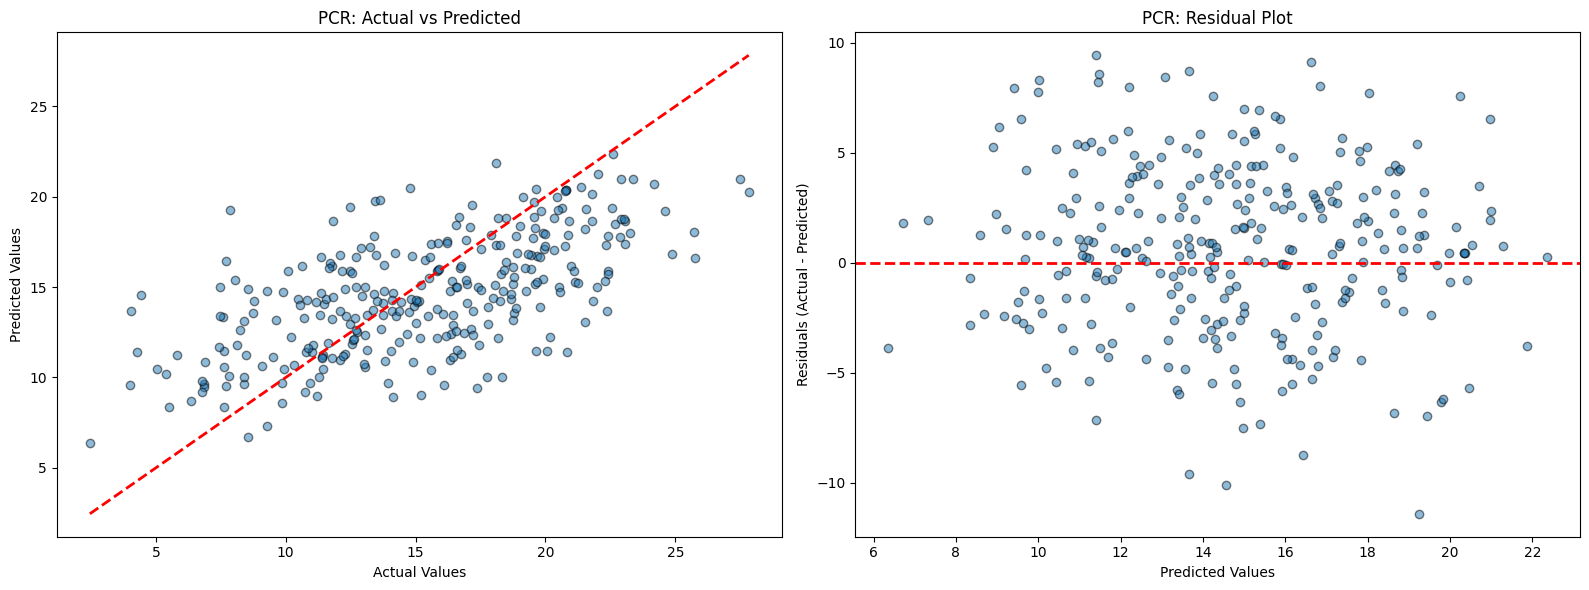

--- Regression Metrics ---
Mean Squared Error (MSE):      15.2790
Root Mean Squared Error (RMSE): 3.9088
Mean Absolute Error (MAE):     3.1396
R2 Score (Variance Explained):  0.3694


array([15.88350395, 20.53768921, 16.15929551, 12.990603  , 13.65169372,
       20.23937827, 17.30409774, 14.81126351, 14.0375807 , 17.0592363 ,
       17.16192171, 14.98392052, 17.38278442, 17.73065889, 10.57442579,
       18.65128545, 17.12211213, 13.63534397, 19.24507632, 13.95508729,
       14.88887434, 15.87050229, 13.39040143, 13.37178041, 14.34115519,
       11.4779287 ,  9.62388946, 18.39023749, 19.78429925, 14.76782499,
       13.13913871, 15.95116492,  8.58157264, 12.65503687, 10.83359216,
       15.31978945, 14.1526095 , 10.42885602, 19.98510302, 20.45454052,
       10.90472953, 12.89831727, 11.41331395, 18.00454262, 19.19059393,
       15.16783488, 14.34657998, 11.39812453, 15.74815923, 18.33827512,
       11.48947621, 12.17006709, 10.45613216, 12.531289  , 11.44161075,
       12.40164719, 10.98187325, 15.17228227,  9.45182491, 10.00087995,
       13.15539137, 18.41320252, 13.70131573, 14.80381059, 19.37175148,
       11.13064682, 19.83417383, 10.66233232, 15.91259919, 16.79

In [103]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# PCR is a pipeline of PCA followed by Linear Regression
reg_pipe.set_params(model=Pipeline([
    ('pca', PCA(n_components=5)),
    ('linear', LinearRegression())
]))

reg_pipe.fit(X_train, y_train)
print(f"PCR R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="PCR")
evaluate_regression(reg_pipe, X_test, y_test)

### Partial Least Squares (PLS) Regression

PLS R^2 on Data: 0.7447


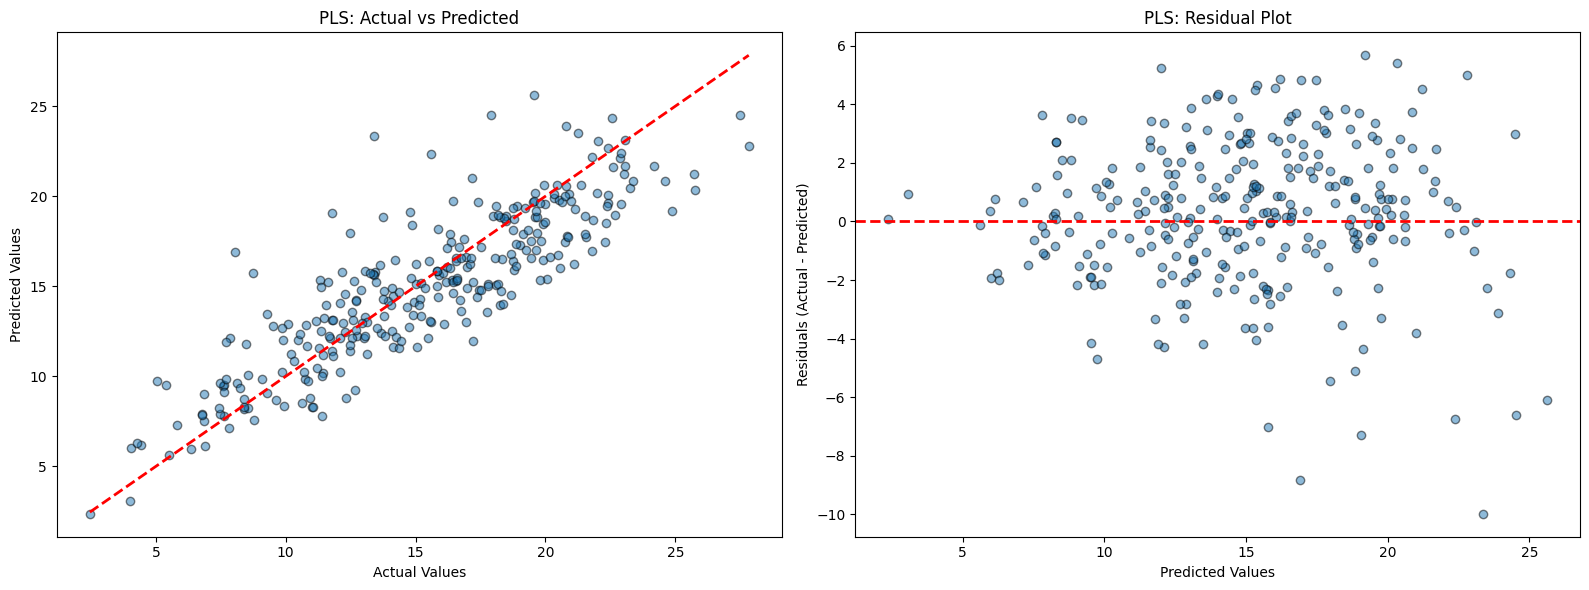

--- Regression Metrics ---
Mean Squared Error (MSE):      6.1867
Root Mean Squared Error (RMSE): 2.4873
Mean Absolute Error (MAE):     1.8982
R2 Score (Variance Explained):  0.7447


array([15.03713118, 20.60856838, 19.05299855, 15.13588794,  5.99538405,
       22.81257424, 15.04874163, 14.70970427, 13.23375023, 19.9223359 ,
       14.77040199, 19.76168437, 22.35498396, 19.68165854, 13.31498556,
       23.09700332, 17.15273719, 12.71689771, 12.11274577, 14.14300311,
       12.47067187, 20.07457254,  8.80416622,  9.4776774 , 13.97259874,
       13.97865729,  7.50824669, 17.26812116, 15.78849884, 17.88679929,
        8.75777013, 14.40130707, 10.26067016, 12.40386018, 13.41313696,
       15.35452062, 11.62688296, 13.00409063, 20.62276992, 19.12604494,
       12.23186348, 19.74479054, 17.8149281 , 16.46806292, 20.84027188,
       16.08216368, 15.48363229, 12.84511832, 22.67282477, 16.22723626,
        7.79188825, 15.13198975, 10.16401607, 12.24555388, 17.00564786,
       17.43726218, 10.26341692, 20.16842537,  9.0269861 , 13.57386731,
        8.67245891, 16.55390889, 12.13148024, 16.99898404, 19.67969065,
       12.81223225, 16.20336774,  9.8428706 , 12.87848685, 14.04

In [104]:
from sklearn.cross_decomposition import PLSRegression

reg_pipe.set_params(model=PLSRegression(n_components=5))
reg_pipe.fit(X_train, y_train)
print(f"PLS R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test).ravel(), model_name="PLS")
evaluate_regression(reg_pipe, X_test, y_test)

### Huber Regression (Robust to Outliers)

Huber Regression R^2 on Data: 0.7436


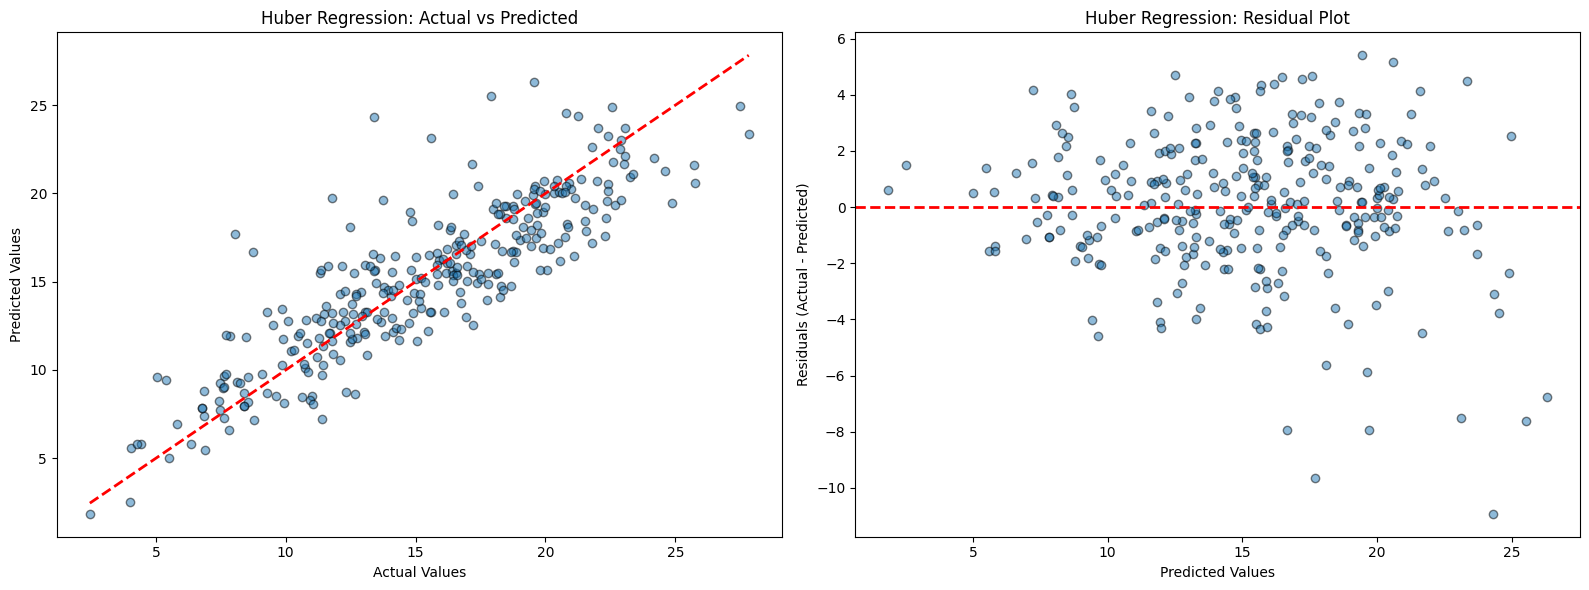

--- Regression Metrics ---
Mean Squared Error (MSE):      6.2118
Root Mean Squared Error (RMSE): 2.4923
Mean Absolute Error (MAE):     1.8653
R2 Score (Variance Explained):  0.7436


array([15.43942526, 20.78878829, 19.72332152, 15.13364962,  5.60631373,
       23.3459178 , 15.44203932, 14.70212196, 13.16371683, 19.99528476,
       14.42950627, 20.08543407, 23.11725428, 19.88735075, 13.30119348,
       23.71965978, 17.29697614, 12.65150962, 11.93085246, 14.36375586,
       12.78154752, 20.54897674,  8.77257678,  8.97839354, 13.62151725,
       14.18917288,  7.39005575, 17.34937181, 15.65230319, 17.90455767,
        8.68385912, 14.78849551, 10.26342683, 12.70320202, 13.23007599,
       15.59019552, 11.62136919, 13.29224507, 20.76115622, 18.94029337,
       11.92840136, 19.9565496 , 18.26776961, 16.89715834, 21.26406955,
       15.89351706, 15.63507741, 12.83148268, 23.22937416, 16.55431234,
        7.30923162, 15.50204124, 10.26546894, 11.82138447, 17.47085021,
       18.11334332, 10.56677741, 20.44695956,  8.80728595, 13.957534  ,
        8.51004294, 17.06143014, 12.5603413 , 17.48628898, 20.02434467,
       12.57064789, 16.33860958,  9.74662923, 12.78321035, 14.31

In [105]:
from sklearn.linear_model import HuberRegressor

reg_pipe.set_params(model=HuberRegressor())
reg_pipe.fit(X_train, y_train)
print(f"Huber Regression R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Huber Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Gaussian Process Regression (GPR)

d:\Code\ML\Practice Code\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GPR R^2 on Data: 0.9983


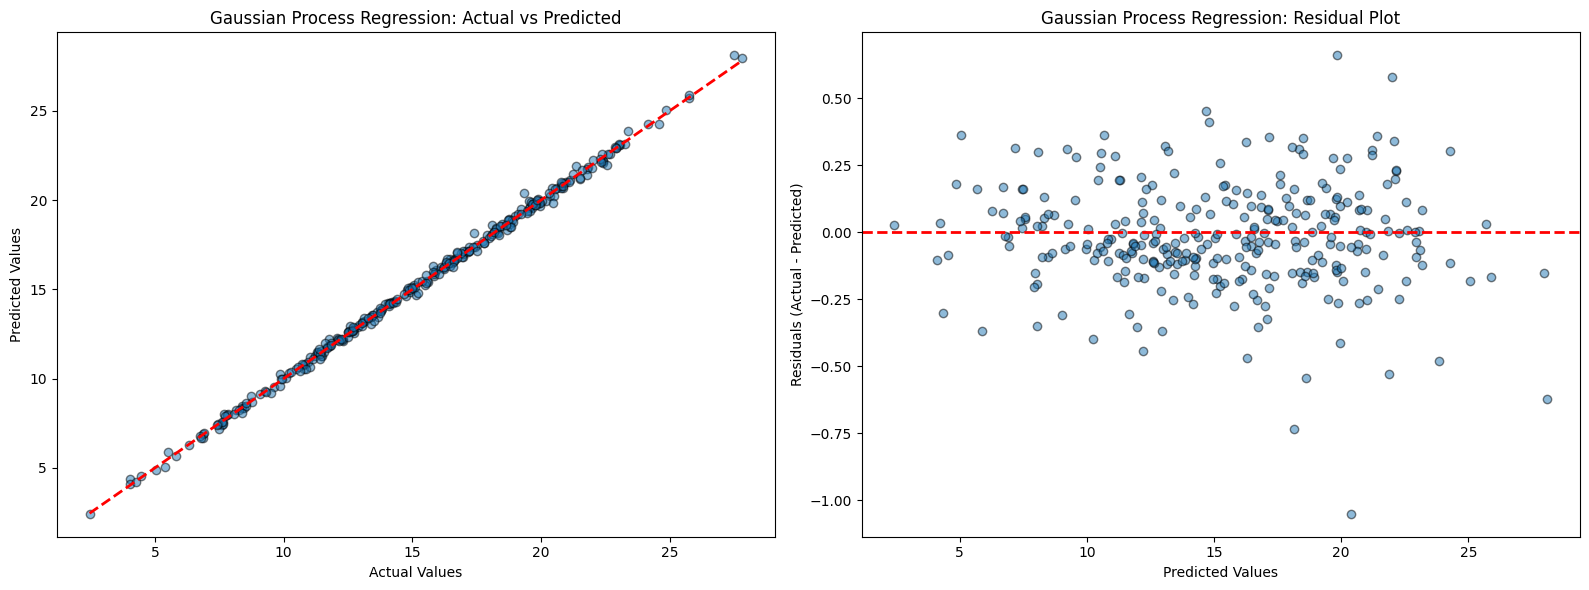

--- Regression Metrics ---
Mean Squared Error (MSE):      0.0401
Root Mean Squared Error (RMSE): 0.2002
Mean Absolute Error (MAE):     0.1483
R2 Score (Variance Explained):  0.9983


array([15.73602285, 21.88365504, 12.2216718 , 15.04692071,  4.3538843 ,
       27.97625576, 18.62139766, 13.87028748, 11.28718834, 20.2211245 ,
       12.88262581, 20.24346902, 15.42554091, 19.57942331, 13.14742366,
       23.0728931 , 17.47209582, 14.62839199,  8.03402956, 15.12475289,
       12.225571  , 22.16813292, 12.11417263,  7.43263832, 11.51341284,
       14.21828069,  6.6926782 , 19.09071981, 13.55575255, 16.46382799,
        8.48983875, 15.97302429, 10.25663176, 13.43018992, 14.8471069 ,
       16.44643573, 15.24848825, 15.46751226, 20.69908514, 14.95260646,
       13.91739064, 16.70948879, 20.69817709, 20.07899649, 24.28650188,
       16.82875878, 15.05935803, 10.52821222, 22.16883156, 17.12439162,
        7.58618703, 18.18868952, 11.25144851, 12.56459068, 19.5694729 ,
       16.71613082, 12.2494539 , 19.60128169,  6.89229527, 17.69912536,
        9.52309435, 16.65196384, 12.19398979, 19.48593804, 20.66936687,
        9.20826881, 13.74948236,  9.13330476, 10.06010565, 12.14

In [106]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
reg_pipe.set_params(model=GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10))
reg_pipe.fit(X_train, y_train)
print(f"GPR R^2 on Data: {reg_pipe.score(X_test, y_test):.4f}")
plot_regression_results(y_test, reg_pipe.predict(X_test), model_name="Gaussian Process Regression")
evaluate_regression(reg_pipe, X_test, y_test)

### Locally Weighted Linear Regression (LWLR)

LWLR R^2 on Data: 0.6510


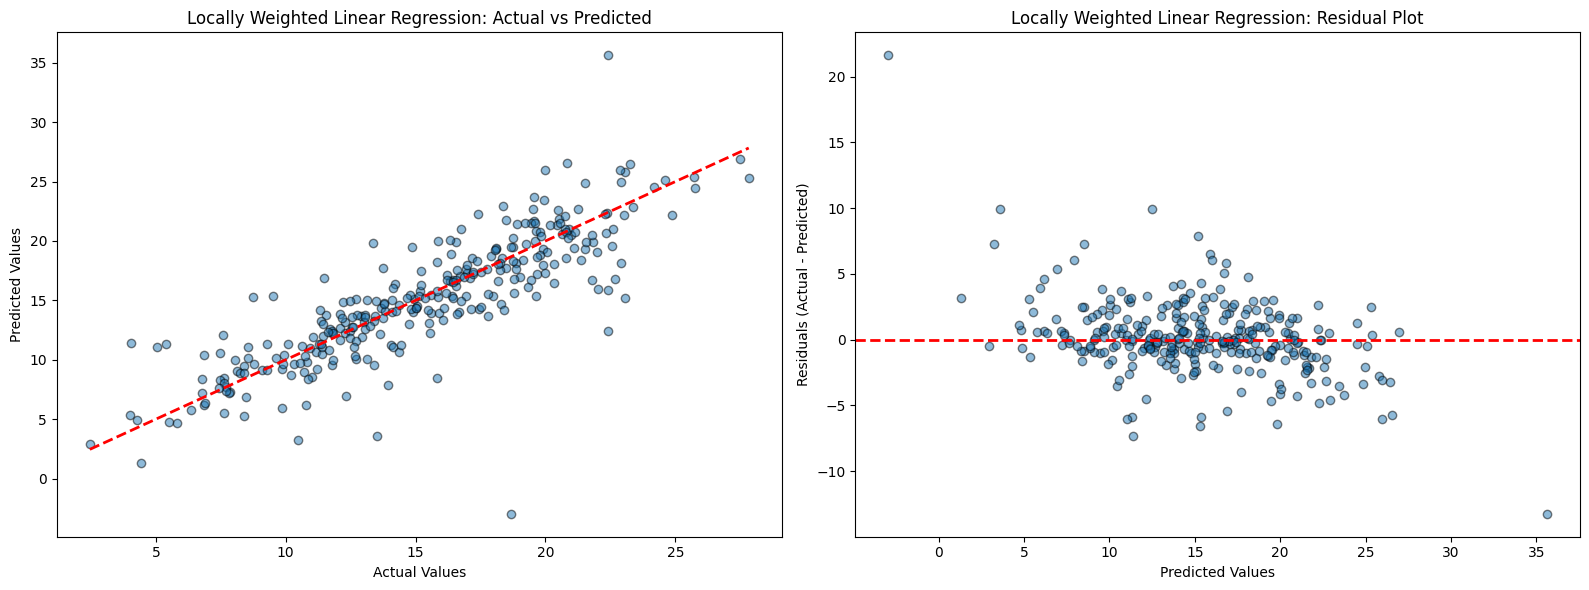

In [107]:
import numpy as np

class LWLR:
    def __init__(self, tau=0.1):
        self.tau = tau
        
    def fit(self, X, y):
        self.X = X
        self.y = y
        return self
        
    def predict(self, X_query):
        predictions = []
        for x_q in X_query:
            # Calculate Gaussian weights
            weights = np.exp(-np.sum((self.X - x_q)**2, axis=1) / (2 * self.tau**2))
            W = np.diag(weights)
            
            # Add intercept term to X
            X_bi = np.hstack([np.ones((self.X.shape[0], 1)), self.X])
            x_q_bi = np.append(1, x_q)
            
            # Solve Weighted Least Squares: beta = (X^T W X)^-1 X^T W y
            try:
                beta = np.linalg.inv(X_bi.T @ W @ X_bi) @ X_bi.T @ W @ self.y
                predictions.append(x_q_bi @ beta)
            except np.linalg.LinAlgError:
                # Handle singular matrix if neighborhood is too small or sparse
                predictions.append(np.mean(self.y))
                
        return np.array(predictions)
    
    def score(self, X, y):
        from sklearn.metrics import r2_score
        return r2_score(y, self.predict(X))

lwlr = LWLR(tau=0.1)
lwlr.fit(X_train, y_train)
y_pred_lwlr = lwlr.predict(X_test)
print(f"LWLR R^2 on Data: {lwlr.score(X_test, y_test):.4f}")
plot_regression_results(y_test, y_pred_lwlr, model_name="Locally Weighted Linear Regression")